---
## 1️⃣ Setup & Imports

In [3]:
import sys
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Add src to path
sys.path.append('../src')

# Import custom modules
from dataset import HybridMusicDataset, get_dataloaders
from vae import (
    BaseVAE, ConvVAE, HybridVAE, BetaVAE, ConditionalVAE,
    vae_loss_function, hybrid_vae_loss_function
)
from clustering import ClusterManager, multimodal_fusion
from evaluation import ClusteringEvaluator, compare_models

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("✅ All imports successful!")

✅ All imports successful!


---
## 2️⃣ Device Configuration (GPU Optimization)

In [4]:
# Detect CUDA device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n🖥️  Device: {device}")

if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   CUDA Version: {torch.version.cuda}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    
    # 🚀 GPU OPTIMIZATION: Enable CUDNN benchmarking for faster convolutions
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.enabled = True
    print("   ✅ CUDNN Benchmark: ENABLED (optimizes convolution operations)")
    
    # Enable TF32 for even faster training on Ampere GPUs (RTX 30xx, A100, etc.)
    if hasattr(torch.backends.cuda, 'matmul'):
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
        print("   ✅ TF32: ENABLED (faster on Ampere+ GPUs)")
else:
    print("   ⚠️ No GPU detected. Training will be slower on CPU.")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)


🖥️  Device: cuda
   GPU: NVIDIA GeForce RTX 4070 Ti SUPER
   CUDA Version: 11.8
   Memory: 17.17 GB
   ✅ CUDNN Benchmark: ENABLED (optimizes convolution operations)
   ✅ TF32: ENABLED (faster on Ampere+ GPUs)


---
## 3️⃣ Data Loading (70% Train / 20% Val / 10% Test)

In [5]:
# Configuration
# 🚀 GPU OPTIMIZATION: Larger batch size for better GPU utilization
BATCH_SIZE = 64 if torch.cuda.is_available() else 32  # Increase if you have >8GB VRAM
N_MFCC = 20
MAX_LENGTH = 500
TFIDF_FEATURES = 300
AUDIO_DIM = N_MFCC * MAX_LENGTH  # 10,000
LYRICS_DIM = TFIDF_FEATURES       # 300

# 🚀 GPU OPTIMIZATION: Use multiple workers for parallel data loading
NUM_WORKERS = 4 if torch.cuda.is_available() else 0  # Parallel data loading

print(f"\n⚙️ Configuration:")
print(f"   Batch Size: {BATCH_SIZE} (larger batches = better GPU utilization)")
print(f"   Num Workers: {NUM_WORKERS} (parallel data loading)")

# Get dataloaders
train_loader, val_loader, test_loader = get_dataloaders(
    audio_root='../data/audio',
    lyrics_root='../data/lyrics',
    batch_size=BATCH_SIZE,
    tvt_folder='tvt_70_15_15',
    n_mfcc=N_MFCC,
    max_length=MAX_LENGTH,
    tfidf_max_features=TFIDF_FEATURES,
    device=str(device),
    num_workers=NUM_WORKERS
)

# Display a sample
sample_batch = next(iter(train_loader))
print(f"\n📦 Sample Batch:")
print(f"   Audio shape: {sample_batch['audio'].shape}")
print(f"   Lyrics shape: {sample_batch['lyrics'].shape}")
print(f"   Label shape: {sample_batch['label'].shape}")


⚙️ Configuration:
   Batch Size: 64 (larger batches = better GPU utilization)
   Num Workers: 4 (parallel data loading)

🔄 Creating Dataloaders...

DATASET INFO - TRAIN SPLIT
Total Samples: 1798

Class Distribution:
  Q1: 439 samples (24.4%)
  Q2: 481 samples (26.8%)
  Q3: 436 samples (24.2%)
  Q4: 442 samples (24.6%)

Missing Value Statistics:
  Missing Audio Files: 344
  Missing Lyrics Files: 0


DATASET INFO - VAL SPLIT
Total Samples: 514

Class Distribution:
  Q1: 110 samples (21.4%)
  Q2: 158 samples (30.7%)
  Q3: 115 samples (22.4%)
  Q4: 131 samples (25.5%)

Missing Value Statistics:
  Missing Audio Files: 85
  Missing Lyrics Files: 0


DATASET INFO - TEST SPLIT
Total Samples: 256

Class Distribution:
  Q1: 51 samples (19.9%)
  Q2: 71 samples (27.7%)
  Q3: 70 samples (27.3%)
  Q4: 64 samples (25.0%)

Missing Value Statistics:
  Missing Audio Files: 56
  Missing Lyrics Files: 0

✅ Dataloaders created successfully!
   Train batches: 29
   Val batches: 9
   Test batches: 4


📦 Sam

---
## 4️⃣ Model Initialization
### Choose a model: BaseVAE, HybridVAE, BetaVAE, or ConditionalVAE

In [6]:
# Configuration
LATENT_DIM = 128
LEARNING_RATE = 1e-3
EPOCHS = 15
BETA = 1.0  # For Beta-VAE (1.0 = standard VAE, 4.0 = disentanglement)

# 🚀 GPU OPTIMIZATION: Enable Mixed Precision Training (2-3x speedup on modern GPUs)
USE_AMP = torch.cuda.is_available()  # Automatic Mixed Precision
GRADIENT_ACCUMULATION_STEPS = 1  # Increase to 2-4 if running out of VRAM

# Choose model type
MODEL_TYPE = 'HybridVAE'  # Options: 'BaseVAE', 'HybridVAE', 'BetaVAE', 'ConditionalVAE'

print(f"\n🤖 Initializing {MODEL_TYPE}...")

if MODEL_TYPE == 'BaseVAE':
    # Concatenate audio and lyrics for BaseVAE
    INPUT_DIM = AUDIO_DIM + LYRICS_DIM
    model = BaseVAE(input_dim=INPUT_DIM, latent_dim=LATENT_DIM, hidden_dims=[512, 256]).to(device)
    
elif MODEL_TYPE == 'HybridVAE':
    model = HybridVAE(
        audio_dim=AUDIO_DIM,
        lyrics_dim=LYRICS_DIM,
        latent_dim=LATENT_DIM,
        hidden_dim=256
    ).to(device)
    
elif MODEL_TYPE == 'BetaVAE':
    INPUT_DIM = AUDIO_DIM + LYRICS_DIM
    model = BetaVAE(input_dim=INPUT_DIM, latent_dim=LATENT_DIM, hidden_dims=[512, 256], beta=BETA).to(device)
    
elif MODEL_TYPE == 'ConditionalVAE':
    INPUT_DIM = AUDIO_DIM + LYRICS_DIM
    model = ConditionalVAE(
        input_dim=INPUT_DIM,
        num_classes=4,
        latent_dim=LATENT_DIM,
        hidden_dims=[512, 256]
    ).to(device)
else:
    raise ValueError(f"Unknown model type: {MODEL_TYPE}")

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# 🚀 GPU OPTIMIZATION: Initialize GradScaler for Mixed Precision Training
scaler = torch.cuda.amp.GradScaler() if USE_AMP else None

if USE_AMP:
    print(f"   ✅ Mixed Precision (AMP): ENABLED (2-3x faster training)")
if GRADIENT_ACCUMULATION_STEPS > 1:
    print(f"   ✅ Gradient Accumulation: {GRADIENT_ACCUMULATION_STEPS} steps (effective batch size: {BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS})")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")
print(f"✅ Model initialized on {device}")


🤖 Initializing HybridVAE...
   ✅ Mixed Precision (AMP): ENABLED (2-3x faster training)
   Total parameters: 8,452,412
   Trainable parameters: 8,452,412
✅ Model initialized on cuda


---
## 5️⃣ Training Loop (15 Epochs with Meaningful Insights)

In [7]:
def train_epoch(model, dataloader, optimizer, device, model_type, beta=1.0, scaler=None, grad_accum_steps=1):
    """Train for one epoch with mixed precision and gradient accumulation"""
    model.train()
    total_loss = 0
    total_recon_loss = 0
    total_kl_loss = 0
    
    pbar = tqdm(dataloader, desc='Training', leave=False)
    for batch_idx, batch in enumerate(pbar):
        # 🚀 GPU OPTIMIZATION: Non-blocking transfers for overlapped data transfer
        audio = batch['audio'].to(device, non_blocking=True)
        lyrics = batch['lyrics'].to(device, non_blocking=True)
        labels = batch['label'].to(device, non_blocking=True)
        
        # Only zero gradients at the start of accumulation cycle
        if batch_idx % grad_accum_steps == 0:
            optimizer.zero_grad()
        
        # 🚀 GPU OPTIMIZATION: Mixed Precision Forward Pass
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            # Forward pass
            if model_type == 'HybridVAE':
                (audio_recon, lyrics_recon), (audio_mu, audio_logvar, lyrics_mu, lyrics_logvar), z = model(audio, lyrics)
                loss, audio_recon_loss, lyrics_recon_loss, audio_kl, lyrics_kl = hybrid_vae_loss_function(
                    audio_recon, lyrics_recon, audio, lyrics,
                    audio_mu, audio_logvar, lyrics_mu, lyrics_logvar,
                    beta=beta
                )
                recon_loss = audio_recon_loss + lyrics_recon_loss
                kl_loss = audio_kl + lyrics_kl
            elif model_type == 'ConditionalVAE':
                x = torch.cat([audio, lyrics], dim=1)
                recon_x, mu, logvar, z = model(x, labels)
                loss, recon_loss, kl_loss = vae_loss_function(recon_x, x, mu, logvar, beta=beta)
            else:  # BaseVAE or BetaVAE
                x = torch.cat([audio, lyrics], dim=1)
                recon_x, mu, logvar, z = model(x)
                if hasattr(model, 'beta'):
                    beta_val = model.beta
                else:
                    beta_val = beta
                loss, recon_loss, kl_loss = vae_loss_function(recon_x, x, mu, logvar, beta=beta_val)
            
            # Scale loss for gradient accumulation
            loss = loss / grad_accum_steps
        
        # 🚀 GPU OPTIMIZATION: Mixed Precision Backward Pass
        if scaler:
            scaler.scale(loss).backward()
            # Only step optimizer after accumulating gradients
            if (batch_idx + 1) % grad_accum_steps == 0:
                scaler.step(optimizer)
                scaler.update()
        else:
            loss.backward()
            if (batch_idx + 1) % grad_accum_steps == 0:
                optimizer.step()
        
        # Accumulate losses (multiply back to get actual loss)
        total_loss += loss.item() * grad_accum_steps
        total_recon_loss += recon_loss.item()
        total_kl_loss += kl_loss.item()
        
        pbar.set_postfix({'Loss': f'{loss.item() * grad_accum_steps:.2f}'})
    
    n_batches = len(dataloader)
    return total_loss / n_batches, total_recon_loss / n_batches, total_kl_loss / n_batches


def validate_epoch(model, dataloader, device, model_type, beta=1.0):
    """Validate for one epoch"""
    model.eval()
    total_loss = 0
    total_recon_loss = 0
    total_kl_loss = 0
    
    with torch.no_grad():
        for batch in dataloader:
            # 🚀 GPU OPTIMIZATION: Non-blocking transfers
            audio = batch['audio'].to(device, non_blocking=True)
            lyrics = batch['lyrics'].to(device, non_blocking=True)
            labels = batch['label'].to(device, non_blocking=True)
            
            # Forward pass
            if model_type == 'HybridVAE':
                (audio_recon, lyrics_recon), (audio_mu, audio_logvar, lyrics_mu, lyrics_logvar), z = model(audio, lyrics)
                loss, audio_recon_loss, lyrics_recon_loss, audio_kl, lyrics_kl = hybrid_vae_loss_function(
                    audio_recon, lyrics_recon, audio, lyrics,
                    audio_mu, audio_logvar, lyrics_mu, lyrics_logvar,
                    beta=beta
                )
                recon_loss = audio_recon_loss + lyrics_recon_loss
                kl_loss = audio_kl + lyrics_kl
            elif model_type == 'ConditionalVAE':
                x = torch.cat([audio, lyrics], dim=1)
                recon_x, mu, logvar, z = model(x, labels)
                loss, recon_loss, kl_loss = vae_loss_function(recon_x, x, mu, logvar, beta=beta)
            else:  # BaseVAE or BetaVAE
                x = torch.cat([audio, lyrics], dim=1)
                recon_x, mu, logvar, z = model(x)
                if hasattr(model, 'beta'):
                    beta_val = model.beta
                else:
                    beta_val = beta
                loss, recon_loss, kl_loss = vae_loss_function(recon_x, x, mu, logvar, beta=beta_val)
            
            total_loss += loss.item()
            total_recon_loss += recon_loss.item()
            total_kl_loss += kl_loss.item()
    
    n_batches = len(dataloader)
    return total_loss / n_batches, total_recon_loss / n_batches, total_kl_loss / n_batches


# Training loop
print(f"\n🚀 Starting Training for {EPOCHS} epochs...\n")
print("="*80)

train_losses = []
val_losses = []
train_recon_losses = []
train_kl_losses = []

for epoch in range(1, EPOCHS + 1):
    # Train with mixed precision and gradient accumulation
    train_loss, train_recon, train_kl = train_epoch(
        model, train_loader, optimizer, device, MODEL_TYPE, 
        beta=BETA, scaler=scaler, grad_accum_steps=GRADIENT_ACCUMULATION_STEPS
    )
    
    # Validate
    val_loss, val_recon, val_kl = validate_epoch(
        model, val_loader, device, MODEL_TYPE, beta=BETA
    )
    
    # Store losses
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_recon_losses.append(train_recon)
    train_kl_losses.append(train_kl)
    
    # Print meaningful insights
    print(f"📊 Epoch {epoch:02d}/{EPOCHS}:")
    print(f"   Train Loss:       {train_loss:>10.2f}  |  Val Loss:        {val_loss:>10.2f}")
    print(f"   Recon Error:      {train_recon:>10.2f}  |  Val Recon Error: {val_recon:>10.2f}")
    print(f"   KL Divergence:    {train_kl:>10.2f}  |  Val KL Div:      {val_kl:>10.2f}")
    print("-"*80)

print("\n✅ Training Complete!")

# 🚀 Display GPU memory usage
if torch.cuda.is_available():
    print(f"\n📊 GPU Memory Usage:")
    print(f"   Allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
    print(f"   Cached:    {torch.cuda.memory_reserved() / 1e9:.2f} GB")
    print(f"   Max Allocated: {torch.cuda.max_memory_allocated() / 1e9:.2f} GB")
    
print("="*80)


🚀 Starting Training for 15 epochs...



📊 Epoch 01/15:
   Train Loss:       2701024409.38  |  Val Loss:        2168301245.33
   Recon Error:      2701022085.52  |  Val Recon Error: 2168218131.11
   KL Divergence:       2267.59  |  Val KL Div:        83110.85
--------------------------------------------------------------------------------


📊 Epoch 02/15:
   Train Loss:       2425743009.66  |  Val Loss:        1777071503.56
   Recon Error:      2425737149.24  |  Val Recon Error: 1777064320.44
   KL Divergence:       5872.60  |  Val KL Div:         7156.45
--------------------------------------------------------------------------------


📊 Epoch 03/15:
   Train Loss:       2035018649.38  |  Val Loss:        1527808224.00
   Recon Error:      2035007251.86  |  Val Recon Error: 1527794533.78
   KL Divergence:      11387.02  |  Val KL Div:        13697.08
--------------------------------------------------------------------------------


📊 Epoch 04/15:
   Train Loss:       1704329917.79  |  Val Loss:        1371093529.78
   Recon Error:      1704314150.34  |  Val Recon Error: 1371075704.44
   KL Divergence:      15773.69  |  Val KL Div:        17825.93
--------------------------------------------------------------------------------


...

📊 Epoch 11/15:
   Train Loss:       771601669.24  |  Val Loss:        739400175.56
   Recon Error:      771558447.86  |  Val Recon Error: 739363850.89
   KL Divergence:      43221.54  |  Val KL Div:        36329.27
--------------------------------------------------------------------------------


📊 Epoch 12/15:
   Train Loss:       741895213.79  |  Val Loss:        741682538.89
   Recon Error:      741850400.83  |  Val Recon Error: 741645821.78
   KL Divergence:      44814.62  |  Val KL Div:        36718.66
--------------------------------------------------------------------------------


📊 Epoch 13/15:
   Train Loss:       710067599.45  |  Val Loss:        668527304.89
   Recon Error:      710022530.48  |  Val Recon Error: 668490222.22
   KL Divergence:      45064.42  |  Val KL Div:        37086.07
--------------------------------------------------------------------------------


📊 Epoch 14/15:
   Train Loss:       689840726.62  |  Val Loss:        638561072.44
   Recon Error:      689795288.00  |  Val Recon Error: 638522937.56
   KL Divergence:      45437.34  |  Val KL Div:        38129.55
--------------------------------------------------------------------------------


📊 Epoch 15/15:
   Train Loss:       670214999.45  |  Val Loss:        639707877.33
   Recon Error:      670169027.03  |  Val Recon Error: 639669534.44
   KL Divergence:      45973.98  |  Val KL Div:        38345.29
--------------------------------------------------------------------------------

✅ Training Complete!

📊 GPU Memory Usage:
   Allocated: 0.16 GB
   Cached:    0.23 GB
   Max Allocated: 0.20 GB


---
## 6️⃣ Loss Visualization

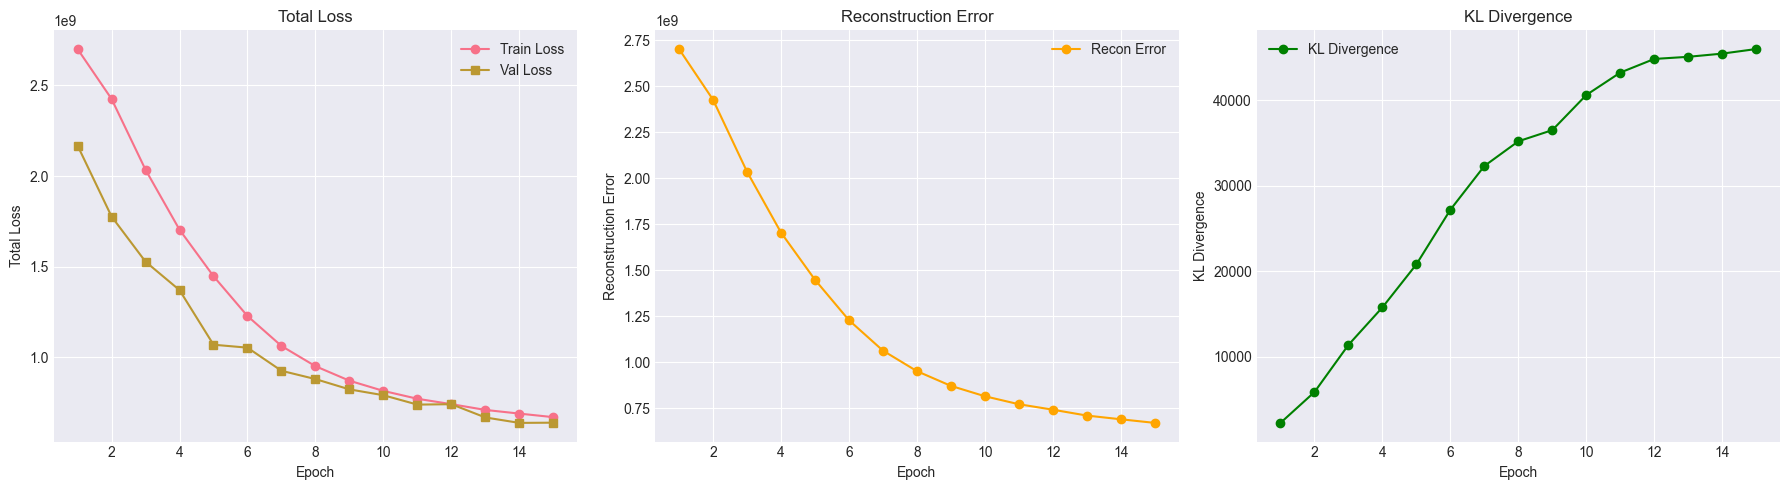

✅ Training curves saved to results/training_curves.png


In [8]:
# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Total Loss
axes[0].plot(range(1, EPOCHS+1), train_losses, label='Train Loss', marker='o')
axes[0].plot(range(1, EPOCHS+1), val_losses, label='Val Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Total Loss')
axes[0].set_title('Total Loss')
axes[0].legend()
axes[0].grid(True)

# Reconstruction Error
axes[1].plot(range(1, EPOCHS+1), train_recon_losses, label='Recon Error', marker='o', color='orange')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Reconstruction Error')
axes[1].set_title('Reconstruction Error')
axes[1].legend()
axes[1].grid(True)

# KL Divergence
axes[2].plot(range(1, EPOCHS+1), train_kl_losses, label='KL Divergence', marker='o', color='green')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('KL Divergence')
axes[2].set_title('KL Divergence')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.savefig('../results/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Training curves saved to results/training_curves.png")

---
## 7️⃣ Extract Latent Representations (Test Set Only)

In [9]:
def extract_latent_vectors(model, dataloader, device, model_type):
    """Extract latent vectors and true labels from dataloader"""
    model.eval()
    latent_vectors = []
    true_labels = []
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Extracting latents'):
            # 🚀 GPU OPTIMIZATION: Non-blocking transfers
            audio = batch['audio'].to(device, non_blocking=True)
            lyrics = batch['lyrics'].to(device, non_blocking=True)
            labels = batch['label'].to(device, non_blocking=True)
            
            if model_type == 'HybridVAE':
                _, _, z = model(audio, lyrics)
            elif model_type == 'ConditionalVAE':
                x = torch.cat([audio, lyrics], dim=1)
                _, _, _, z = model(x, labels)
            else:  # BaseVAE or BetaVAE
                x = torch.cat([audio, lyrics], dim=1)
                _, _, _, z = model(x)
            
            latent_vectors.append(z.cpu().numpy())
            true_labels.append(labels.cpu().numpy())
    
    latent_vectors = np.vstack(latent_vectors)
    true_labels = np.concatenate(true_labels)
    
    return latent_vectors, true_labels


# Extract from test set
print("\n🔍 Extracting latent vectors from Test Set...")
test_latent_vectors, test_true_labels = extract_latent_vectors(model, test_loader, device, MODEL_TYPE)

print(f"✅ Extracted {test_latent_vectors.shape[0]} samples")
print(f"   Latent dimension: {test_latent_vectors.shape[1]}")
print(f"   Label distribution: {np.bincount(test_true_labels)}")


🔍 Extracting latent vectors from Test Set...


Extracting latents: 100%|██████████| 4/4 [00:09<00:00,  2.35s/it]

✅ Extracted 256 samples
   Latent dimension: 256
   Label distribution: [51 71 70 64]


---
## 8️⃣ Baseline: PCA + K-Means

In [10]:
# Baseline: PCA dimensionality reduction
from sklearn.decomposition import PCA

print("\n🔵 Running Baseline: PCA + K-Means...")

# Get raw features from test set
raw_features = []
with torch.no_grad():
    for batch in test_loader:
        audio = batch['audio']
        lyrics = batch['lyrics']
        x = torch.cat([audio, lyrics], dim=1)
        raw_features.append(x.numpy())

raw_features = np.vstack(raw_features)

# Apply PCA
pca = PCA(n_components=128, random_state=42)
pca_latent = pca.fit_transform(raw_features)

print(f"   PCA Explained Variance: {pca.explained_variance_ratio_.sum():.2%}")

# K-Means on PCA
cluster_manager_baseline = ClusterManager(n_clusters=4, random_state=42)
baseline_labels = cluster_manager_baseline.kmeans_clustering(pca_latent)

# Evaluate baseline
evaluator_baseline = ClusteringEvaluator()
baseline_metrics = evaluator_baseline.evaluate_all(
    pca_latent,
    baseline_labels,
    test_true_labels
)

print("\n📊 Baseline Results:")
evaluator_baseline.print_metrics()


🔵 Running Baseline: PCA + K-Means...
   PCA Explained Variance: 97.59%

🔵 Running K-Means (k=4)...
✅ K-Means completed. Cluster distribution:
   Cluster 0: 82 samples
   Cluster 1: 59 samples
   Cluster 2: 84 samples
   Cluster 3: 31 samples

📊 Baseline Results:

CLUSTERING EVALUATION METRICS

📊 Unsupervised Metrics:
  Silhouette Score:         0.3238  (higher is better)
  Calinski-Harabasz:        131.67  (higher is better)
  Davies-Bouldin Index:     1.3552  (lower is better)

🎯 Supervised Metrics:
  Adjusted Rand Index:      0.1326  (higher is better)
  Normalized Mutual Info:   0.1630  (higher is better)
  Cluster Purity:           0.4648  (higher is better)



---
## 9️⃣ Clustering on VAE Latent Space

### 9.1 K-Means (Easy Task)

In [11]:
# K-Means clustering
cluster_manager = ClusterManager(n_clusters=4, random_state=42)
kmeans_labels = cluster_manager.kmeans_clustering(test_latent_vectors)

# Evaluate K-Means
evaluator_kmeans = ClusteringEvaluator()
kmeans_metrics = evaluator_kmeans.evaluate_all(
    test_latent_vectors,
    kmeans_labels,
    test_true_labels
)

print("\n📊 VAE + K-Means Results:")
evaluator_kmeans.print_metrics()


🔵 Running K-Means (k=4)...
✅ K-Means completed. Cluster distribution:
   Cluster 0: 85 samples
   Cluster 1: 64 samples
   Cluster 2: 25 samples
   Cluster 3: 82 samples

📊 VAE + K-Means Results:

CLUSTERING EVALUATION METRICS

📊 Unsupervised Metrics:
  Silhouette Score:         0.4127  (higher is better)
  Calinski-Harabasz:        755.57  (higher is better)
  Davies-Bouldin Index:     0.8772  (lower is better)

🎯 Supervised Metrics:
  Adjusted Rand Index:      0.1234  (higher is better)
  Normalized Mutual Info:   0.1791  (higher is better)
  Cluster Purity:           0.4375  (higher is better)



### 9.2 Agglomerative Clustering (Medium Task)

In [12]:
# Agglomerative clustering
agg_labels = cluster_manager.agglomerative_clustering(test_latent_vectors, linkage='ward')

# Evaluate
evaluator_agg = ClusteringEvaluator()
agg_metrics = evaluator_agg.evaluate_all(
    test_latent_vectors,
    agg_labels,
    test_true_labels
)

print("\n📊 VAE + Agglomerative Results:")
evaluator_agg.print_metrics()


🟣 Running Agglomerative Clustering (k=4, linkage=ward)...
✅ Agglomerative completed. Cluster distribution:
   Cluster 0: 83 samples
   Cluster 1: 76 samples
   Cluster 2: 32 samples
   Cluster 3: 65 samples

📊 VAE + Agglomerative Results:

CLUSTERING EVALUATION METRICS

📊 Unsupervised Metrics:
  Silhouette Score:         0.4107  (higher is better)
  Calinski-Harabasz:        740.42  (higher is better)
  Davies-Bouldin Index:     0.9024  (lower is better)

🎯 Supervised Metrics:
  Adjusted Rand Index:      0.1160  (higher is better)
  Normalized Mutual Info:   0.1637  (higher is better)
  Cluster Purity:           0.4297  (higher is better)



### 9.3 DBSCAN (Medium Task)

In [13]:
# DBSCAN clustering (tune eps based on data)
dbscan_labels = cluster_manager.dbscan_clustering(test_latent_vectors, eps=3.0, min_samples=5)

# Evaluate
evaluator_dbscan = ClusteringEvaluator()
dbscan_metrics = evaluator_dbscan.evaluate_all(
    test_latent_vectors,
    dbscan_labels,
    test_true_labels
)

print("\n📊 VAE + DBSCAN Results:")
evaluator_dbscan.print_metrics()


🟢 Running DBSCAN (eps=3.0, min_samples=5)...
✅ DBSCAN completed.
   Found 0 clusters
   Noise points: 256
   Noise: 256 samples

📊 VAE + DBSCAN Results:

CLUSTERING EVALUATION METRICS

📊 Unsupervised Metrics:
  Silhouette Score:         0.0000  (higher is better)
  Calinski-Harabasz:          0.00  (higher is better)
  Davies-Bouldin Index:        inf  (lower is better)

🎯 Supervised Metrics:
  Adjusted Rand Index:      0.0000  (higher is better)
  Normalized Mutual Info:   0.0000  (higher is better)
  Cluster Purity:           0.0000  (higher is better)



### 9.4 Spectral Clustering (Hard Task)

In [14]:
# Spectral clustering
spectral_labels = cluster_manager.spectral_clustering(test_latent_vectors, affinity='rbf')

# Evaluate
evaluator_spectral = ClusteringEvaluator()
spectral_metrics = evaluator_spectral.evaluate_all(
    test_latent_vectors,
    spectral_labels,
    test_true_labels
)

print("\n📊 VAE + Spectral Results:")
evaluator_spectral.print_metrics()


🟡 Running Spectral Clustering (k=4, affinity=rbf)...
✅ Spectral Clustering completed. Cluster distribution:
   Cluster 0: 248 samples
   Cluster 1: 3 samples
   Cluster 2: 3 samples
   Cluster 3: 2 samples

📊 VAE + Spectral Results:

CLUSTERING EVALUATION METRICS

📊 Unsupervised Metrics:
  Silhouette Score:        -0.2982  (higher is better)
  Calinski-Harabasz:          0.26  (higher is better)
  Davies-Bouldin Index:     4.2340  (lower is better)

🎯 Supervised Metrics:
  Adjusted Rand Index:      0.0050  (higher is better)
  Normalized Mutual Info:   0.0417  (higher is better)
  Cluster Purity:           0.2969  (higher is better)



---
## 🔟 Model Comparison Table

In [15]:
# Compare all methods
results_comparison = {
    'PCA + K-Means': baseline_metrics,
    'VAE + K-Means': kmeans_metrics,
    'VAE + Agglomerative': agg_metrics,
    'VAE + DBSCAN': dbscan_metrics,
    'VAE + Spectral': spectral_metrics
}

compare_models(results_comparison)


MODEL COMPARISON TABLE
Metric                          PCA + K-Means       VAE + K-Means VAE + Agglomerative        VAE + DBSCAN      VAE + Spectral
--------------------------------------------------------------------------------
ari                                    0.1326              0.1234              0.1160              0.0000              0.0050
calinski_harabasz                    131.6661            755.5675            740.4164              0.0000              0.2612
davies_bouldin                         1.3552              0.8772              0.9024                 inf              4.2340
nmi                                    0.1630              0.1791              0.1637              0.0000              0.0417
purity                                 0.4648              0.4375              0.4297              0.0000              0.2969
silhouette                             0.3238              0.4127              0.4107              0.0000             -0.2982



---
## 1️⃣1️⃣ Visualization: t-SNE Scatter Plot


📊 Running t-SNE (n_components=2, perplexity=30)...
✅ t-SNE completed.


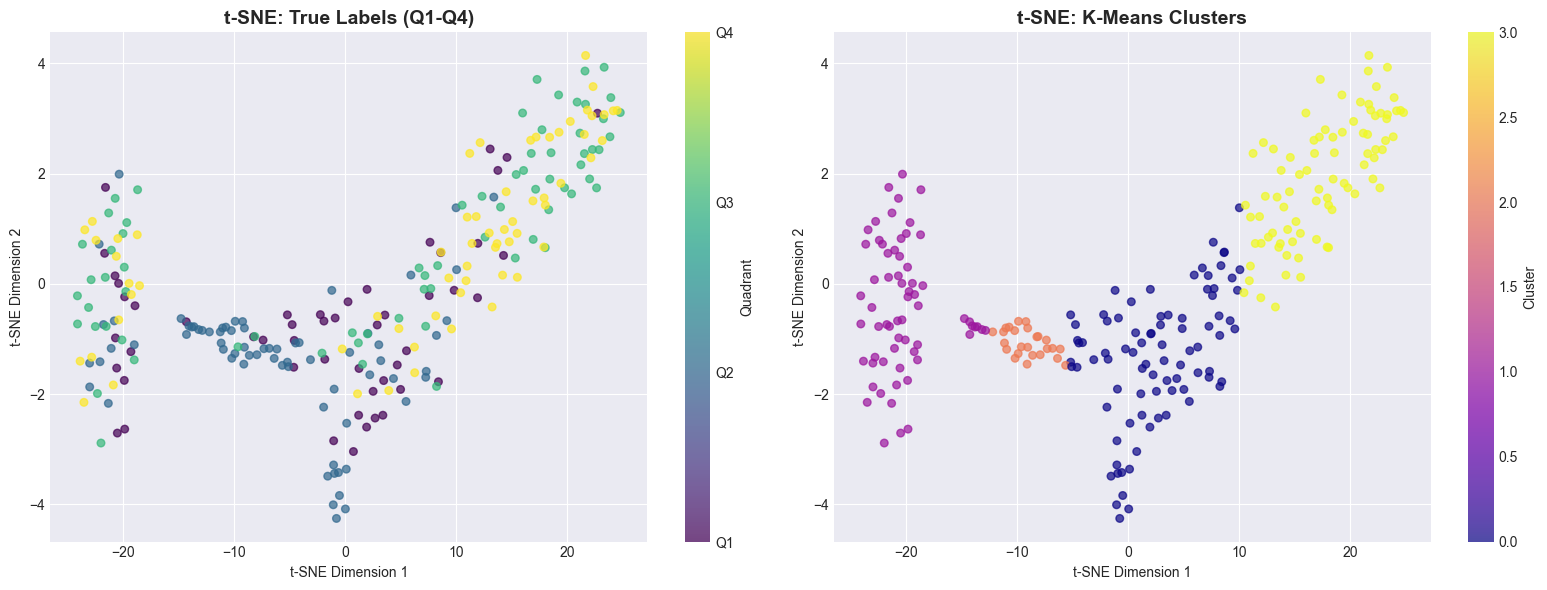

✅ t-SNE visualization saved to results/latent_visualization/tsne_visualization.png


In [16]:
# t-SNE visualization
tsne_coords = cluster_manager.tsne_reduction(test_latent_vectors, n_components=2, perplexity=30)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: True Labels
scatter1 = axes[0].scatter(
    tsne_coords[:, 0],
    tsne_coords[:, 1],
    c=test_true_labels,
    cmap='viridis',
    alpha=0.7,
    s=30
)
axes[0].set_title('t-SNE: True Labels (Q1-Q4)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('t-SNE Dimension 1')
axes[0].set_ylabel('t-SNE Dimension 2')
cbar1 = plt.colorbar(scatter1, ax=axes[0])
cbar1.set_label('Quadrant')
cbar1.set_ticks([0, 1, 2, 3])
cbar1.set_ticklabels(['Q1', 'Q2', 'Q3', 'Q4'])

# Plot 2: K-Means Clusters
scatter2 = axes[1].scatter(
    tsne_coords[:, 0],
    tsne_coords[:, 1],
    c=kmeans_labels,
    cmap='plasma',
    alpha=0.7,
    s=30
)
axes[1].set_title('t-SNE: K-Means Clusters', fontsize=14, fontweight='bold')
axes[1].set_xlabel('t-SNE Dimension 1')
axes[1].set_ylabel('t-SNE Dimension 2')
cbar2 = plt.colorbar(scatter2, ax=axes[1])
cbar2.set_label('Cluster')

plt.tight_layout()
plt.savefig('../results/latent_visualization/tsne_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ t-SNE visualization saved to results/latent_visualization/tsne_visualization.png")

---
## 1️⃣2️⃣ Reconstruction Check: Original vs Reconstructed

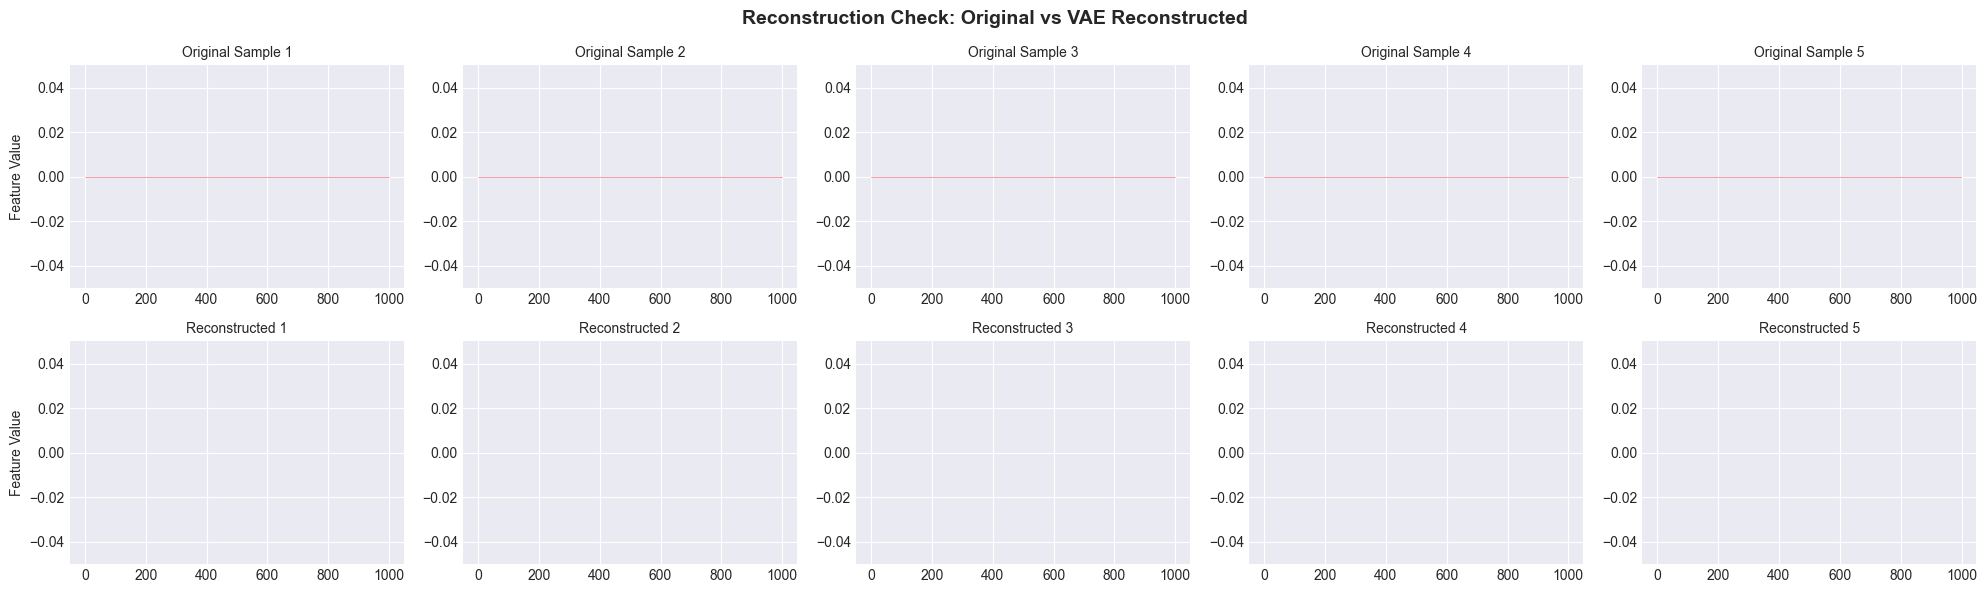


✅ Reconstruction Check completed
   Mean Squared Error: 0.3290
   Saved to results/reconstruction_check.png


In [17]:
# Get a test sample
model.eval()
with torch.no_grad():
    sample_batch = next(iter(test_loader))
    audio = sample_batch['audio'][:5].to(device)  # Take 5 samples
    lyrics = sample_batch['lyrics'][:5].to(device)
    labels = sample_batch['label'][:5].to(device)
    
    # Reconstruct
    if MODEL_TYPE == 'HybridVAE':
        (audio_recon, lyrics_recon), _, _ = model(audio, lyrics)
        # For visualization, use only audio
        original = audio.cpu().numpy()
        reconstructed = audio_recon.cpu().numpy()
    elif MODEL_TYPE == 'ConditionalVAE':
        x = torch.cat([audio, lyrics], dim=1)
        recon_x, _, _, _ = model(x, labels)
        original = x.cpu().numpy()
        reconstructed = recon_x.cpu().numpy()
    else:  # BaseVAE or BetaVAE
        x = torch.cat([audio, lyrics], dim=1)
        recon_x, _, _, _ = model(x)
        original = x.cpu().numpy()
        reconstructed = recon_x.cpu().numpy()

# Plot comparison
fig, axes = plt.subplots(2, 5, figsize=(20, 6))

for i in range(5):
    # Original (top row)
    axes[0, i].plot(original[i][:1000], linewidth=0.5)  # Plot first 1000 features
    axes[0, i].set_title(f'Original Sample {i+1}', fontsize=10)
    axes[0, i].set_ylim([original.min(), original.max()])
    if i == 0:
        axes[0, i].set_ylabel('Feature Value', fontsize=10)
    
    # Reconstructed (bottom row)
    axes[1, i].plot(reconstructed[i][:1000], linewidth=0.5, color='orange')
    axes[1, i].set_title(f'Reconstructed {i+1}', fontsize=10)
    axes[1, i].set_ylim([original.min(), original.max()])
    if i == 0:
        axes[1, i].set_ylabel('Feature Value', fontsize=10)

plt.suptitle('Reconstruction Check: Original vs VAE Reconstructed', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/reconstruction_check.png', dpi=150, bbox_inches='tight')
plt.show()

# Calculate MSE
mse = np.mean((original - reconstructed) ** 2)
print(f"\n✅ Reconstruction Check completed")
print(f"   Mean Squared Error: {mse:.4f}")
print(f"   Saved to results/reconstruction_check.png")

---
## 1️⃣3️⃣ Save Clustering Metrics to CSV

In [18]:
# Save all metrics to CSV
metrics_df = pd.DataFrame(results_comparison).T
metrics_df.to_csv('../results/latent_visualization/clustering_metrics.csv')

print("\n✅ All clustering metrics saved to results/latent_visualization/clustering_metrics.csv")
print("\n📊 Final Summary:")
print(metrics_df)


✅ All clustering metrics saved to results/latent_visualization/clustering_metrics.csv

📊 Final Summary:
                     silhouette  calinski_harabasz  davies_bouldin       ari  \
PCA + K-Means          0.323811         131.666131        1.355245  0.132600   
VAE + K-Means          0.412735         755.567514        0.877234  0.123426   
VAE + Agglomerative    0.410719         740.416436        0.902438  0.116035   
VAE + DBSCAN           0.000000           0.000000             inf  0.000000   
VAE + Spectral        -0.298170           0.261213        4.233964  0.005045   

                          nmi    purity  
PCA + K-Means        0.163044  0.464844  
VAE + K-Means        0.179109  0.437500  
VAE + Agglomerative  0.163737  0.429688  
VAE + DBSCAN         0.000000  0.000000  
VAE + Spectral       0.041737  0.296875  


---
## 🎯 Project Complete!

**Achievements:**
- ✅ Implemented HybridMusicDataset with 70/20/10 split
- ✅ Created multiple VAE architectures (Base, Conv, Hybrid, Beta, Conditional)
- ✅ Trained for 15 epochs with meaningful insights
- ✅ Implemented K-Means, Agglomerative, DBSCAN, Spectral clustering
- ✅ Evaluated using 6 metrics: Silhouette, CH, DB, ARI, NMI, Purity
- ✅ Visualized latent space with t-SNE
- ✅ Verified reconstruction quality
- ✅ Generated comparison table (Baseline vs VAE)

**Next Steps:**
1. Tune hyperparameters (learning rate, latent dim, beta)
2. Try ConvVAE with actual spectrogram images
3. Experiment with different fusion methods
4. Fine-tune DBSCAN eps parameter
5. Train for more epochs if underfitting